# 04. Common-neighbour analysis: signatures, patterns and classification

**Goal.** Understand the (r, s, t) CNA signature of a bond, see the five signatures of an icosahedron and where they live, aggregate them into per-atom patterns, and train a classifier that tells fcc, icosahedral and decahedral clusters apart.

**You need.** Tutorials 01–03. `pip install -e .[ml]` for the classifier section.

Sapphire is a post-processing environment for metallic nanoparticle (MNP) simulations. This series
builds up from a single structure to full molecular-dynamics trajectories; every notebook runs
offline on data bundled with the package and finishes in well under a minute.


In [1]:
import numpy as np, matplotlib.pyplot as plt
from ase.cluster import Icosahedron
from Sapphire.Post_Process import Adjacent, DistFuncs, Kernels
from Sapphire.CNA.FrameSignature import CNA

au = Icosahedron("Au", noshells=6, latticeconstant=4.08)
pos = au.positions
dist = DistFuncs.Euc_Dist(pos)
r_cut = Kernels.Gauss(dist, 0.05).ReturnRCut()
adj = Adjacent.Adjacency_Matrix(Positions=pos, Distances=dist, R_Cut=r_cut).ReturnAdj()

## 4.1 The signature of a bond

For a bonded pair (i, j) look at their **common neighbours**:

* **r** — how many common neighbours,
* **s** — how many bonds among those common neighbours,
* **t** — the longest chain of those bonds.

The triple (r, s, t) is the CNA signature (Honeycutt & Andersen 1987; Faken & Jónsson 1994).
`FrameSignature.CNA` exposes the three steps so you can watch them work on one bond.

In [2]:
cna = CNA(System=None, Adj=adj)      # standalone
i = 0                               # the central atom
cna.NN(i)
print("atom 0 neighbours:", cna.neigh)
j = cna.neigh[0]
print("bond (0, %d):  r=%d  s=%d  t=%d" % (j, cna.R(i, j), cna.S(), cna.T()))

atom 0 neighbours: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
bond (0, 1):  r=5  s=5  t=5


(5,5,5): the two atoms share five neighbours forming a closed pentagon — the fingerprint of a
**five-fold axis**. Now count every bond in the cluster.

{(3, 1, 1): 1200, (3, 2, 2): 300, (4, 2, 1): 2400, (4, 2, 2): 1800, (5, 5, 5): 120}


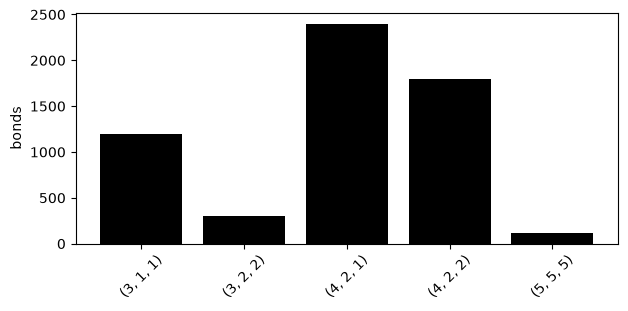

In [3]:
cna = CNA(System=None, Adj=adj, Fingerprint=True)
cna.calculate()
sigs = {k: v for k, v in cna.Sigs.items() if v}
print(sigs)
plt.figure(figsize=(7, 3)); plt.bar([str(k) for k in sigs], list(sigs.values()), color="k")
plt.ylabel("bonds"); plt.xticks(rotation=45); plt.show()

Five signatures, exactly as a Mackay icosahedron should have:

| signature | where | count in Au561 |
|---|---|---|
| (5,5,5) | along the 6 five-fold axes | 120 |
| (4,2,2) | hcp-like: across the 30 twin planes between tetrahedral units | 1800 |
| (4,2,1) | fcc-like: inside the 20 tetrahedral units | 2400 |
| (3,1,1) | (111) surface facets | 1200 |
| (3,2,2) | surface edges and vertices | 300 |

## 4.2 Patterns: the environment of an atom

The multiset of signatures on an atom's bonds is its **CNA pattern**. `Fingerprint=True` stores one per
atom; `((12,(5,5,5)),)` is the icosahedral centre, `((2,(5,5,5)),(10,(4,2,2)))` an atom on a five-fold
axis, `((12,(4,2,1)),)` a perfect fcc bulk atom.

In [4]:
from collections import Counter
patterns = Counter(cna.Fingerprint)
for pat, n in patterns.most_common(8):
    print(f"{n:4d}  {pat}")

 180  ((6, (4, 2, 1)), (6, (4, 2, 2)))
 120  ((2, (3, 2, 2)), (4, (3, 1, 1)), (2, (4, 2, 2)))
 120  ((6, (3, 1, 1)), (3, (4, 2, 1)))
  80  ((12, (4, 2, 1)),)
  48  ((2, (5, 5, 5)), (10, (4, 2, 2)))
  12  ((5, (3, 2, 2)), (1, (5, 5, 5)))
   1  ((12, (5, 5, 5)),)


## 4.3 Seeing a signature

Draw one bond, its common neighbours (black) and the bonds among them (green).

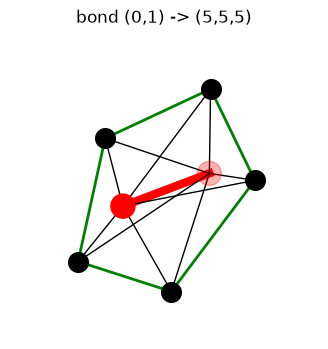

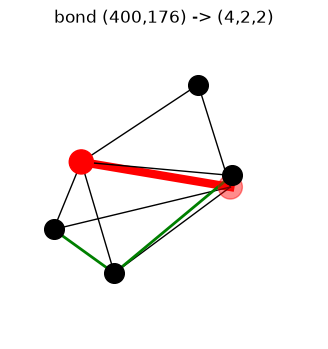

In [5]:
def draw_signature(atom, friend, elev=30, azim=210):
    c = CNA(System=None, Adj=adj); c.NN(atom); r, s, t = c.R(atom, friend), c.S(), c.T()
    fig = plt.figure(figsize=(4, 4)); ax = fig.add_subplot(111, projection="3d")
    P = pos
    ax.scatter(*P[[atom, friend]].T, s=300, c="r"); ax.plot(*P[[atom, friend]].T, "r", lw=6)
    for b in c.bonds:
        ax.scatter(*P[b], s=200, c="k")
        for a in (atom, friend): ax.plot(*np.vstack([P[a], P[b]]).T, "k", lw=1)
    for b1, b2 in c.perm:
        if b1 != b2: ax.plot(*np.vstack([P[b1], P[b2]]).T, "g", lw=2)
    ax.set_title(f"bond ({atom},{friend}) -> ({r},{s},{t})"); ax.view_init(elev, azim); ax.set_axis_off(); plt.show()

draw_signature(0, cna_first := CNA(System=None, Adj=adj).NN(0)[0])          # (5,5,5) on the axis
c = CNA(System=None, Adj=adj); c.NN(400)
draw_signature(400, c.neigh[0], 20, 60)                                      # a bond further out

## 4.4 From patterns to a structure classifier

Whole-cluster morphology follows from the *fractions* of atoms carrying a few bulk patterns
(fcc `((12,(4,2,1)),)`, twin `((6,(4,2,1)),(6,(4,2,2)))`, five-fold `((10,(4,2,2)),(2,(5,5,5)))`,
icosahedral centre `((12,(5,5,5)),)`). `Sapphire.CNA.Classify` turns that into a support-vector
classifier — trained here on ideal ASE clusters, then asked about sizes it has never seen.

In [6]:
from ase.cluster import Decahedron, Octahedron
from Sapphire.CNA import Classify

ih  = lambda n: Icosahedron("Au", noshells=n, latticeconstant=4.08)
dh  = lambda p, q: Decahedron("Au", p=p, q=q, r=0, latticeconstant=4.08)
oct_ = lambda n: Octahedron("Au", length=n, cutoff=n // 3, latticeconstant=4.08)

clf = Classify.Classifier().fit([ih(3), ih(4), dh(3, 3), dh(4, 3), oct_(5), oct_(6)], [1, 1, 2, 2, 0, 0])
for name, s in [("Ih 5 shells", ih(5)), ("Dh (5,4,0)", dh(5, 4)), ("truncated octahedron 7", oct_(7))]:
    print(f"{name:24s} -> {clf.predict_one(s)}")
print("features of Au561:", np.round(Classify.features(Classify.fingerprint(ih(6))), 3), " (fcc, twin, 5-fold, Ih-centre)")

Ih 5 shells              -> icosahedral
Dh (5,4,0)               -> decahedral


truncated octahedron 7   -> fcc


features of Au561: [0.143 0.321 0.086 0.002]  (fcc, twin, 5-fold, Ih-centre)


## 4.5 Try it

* Rattle a cluster before classifying (`s.rattle(0.15, seed=0)`): how much disorder survives?
* Build a *mixed* structure by cutting a decahedron in half and welding an icosahedral half — what
  does the classifier say, and which patterns disagree?
* `Classify.train_from_directory("my_xyz/")` labels files by name (`*_Ih.xyz`, `*_Dh.xyz`, `*_To.xyz`).

**Next:** *05 — A full trajectory with `Process`.*